# Task 9: Implementing Parameter Fitting

## Importing Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.optimize import minimize

## Defining helper functions for the simulation

In [2]:
def func(y0, t, alpha, beta, delta, gamma):
    dxdt = (alpha * y0[0]) - (beta * y0[0] * y0[1])
    dydt = (delta * y0[0] * y0[1]) - (gamma * y0[1])
    return dxdt, dydt

def plt_sim(t, y):
    plt.plot(t, y[:, 0], label="Prey")
    plt.plot(t, y[:, 1], label="Predator")
    plt.legend()
    plt.ylabel("Populations Size")
    plt.xlabel("Time")
    plt.show()

## Defining key parameters

In [3]:
# Prey, Predator
y0 = [10, 10]
alpha, beta = 0.1, 0.02
delta, gamma = 0.02, 0.4
end_time = 100
n_samples = 1000
t = np.linspace(0, end_time, n_samples)

## Generating training data

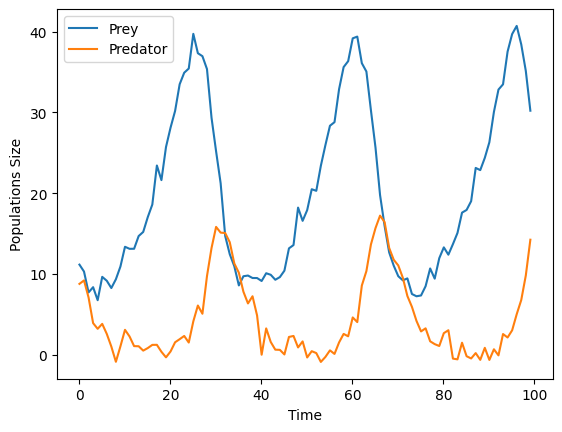

In [4]:
y = odeint(func, y0, t, args=(alpha, beta, delta, gamma))
y_noised = y + np.random.normal(0, 1, (1000, 2))
plt_sim(t[::10], y_noised[::10])

## Fitting the parameters

Parameters Predicted:  [0.09976699 0.01999338 0.0200478  0.40112102]


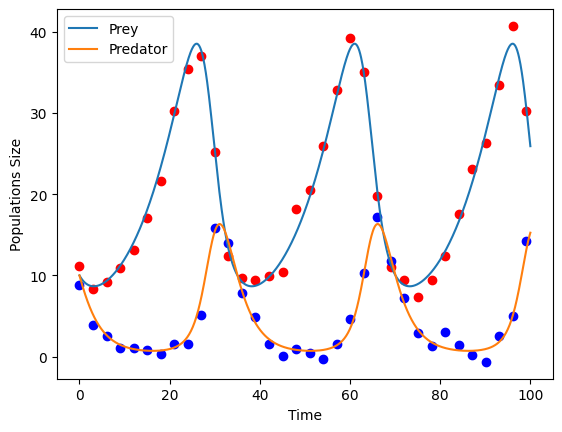

In [5]:
def fit_loss(params, y_noised):
    res = odeint(func, y0, t, args=tuple(params))
    loss = 0
    for step in range(len(t)):
        loss += (y_noised[:,0][step] - res[:, 0][step])**2 + (y_noised[:,1][step] - res[:, 1][step])**2
    return loss

res_min = minimize(fit_loss, [alpha, beta, delta, gamma], args=(y_noised,), method="Nelder-Mead")

print("Parameters Predicted: ", res_min.x)
y = odeint(func, y0, t, args=tuple(res_min.x))
plt.scatter(t[::30], y_noised[:,0][::30], c='r')
plt.scatter(t[::30], y_noised[:,1][::30], c='b')
plt_sim(t, y)